In [1]:
from src.lib.new_drivers import *
from serial.tools import list_ports
import time
from matplotlib import pyplot as plt

In [2]:
ports = list_ports.comports()
for port in ports:
    print(port.device)

/dev/ttyS4
/dev/ttyS31
/dev/ttyS30
/dev/ttyS29
/dev/ttyS28
/dev/ttyS27
/dev/ttyS26
/dev/ttyS25
/dev/ttyS24
/dev/ttyS23
/dev/ttyS22
/dev/ttyS21
/dev/ttyS20
/dev/ttyS19
/dev/ttyS18
/dev/ttyS17
/dev/ttyS16
/dev/ttyS15
/dev/ttyS14
/dev/ttyS13
/dev/ttyS12
/dev/ttyS11
/dev/ttyS10
/dev/ttyS9
/dev/ttyS8
/dev/ttyS7
/dev/ttyS6
/dev/ttyS5
/dev/ttyS3
/dev/ttyS2
/dev/ttyS1
/dev/ttyS0
/dev/ttyUSB0


identify: *IDN?

reset: *RST

clear: *CLS

operation_complete: *OPC

zero_check_on: SYST:ZCH ON

zero_check_off: SYST:ZCH OFF

configure_current: CONF:CURR:DC

configure_resistance: CONF:RES

format_elements: FORM:ELEM READ,TST

reset_time: SYST:TST:REL:RES

query_zero_check: SYST:ZCH?


Testa il finto elettrometro.

Il led viene acceso o spento in base al valore dello zero check.

Il valore di resistenza letto è impostato dal potenziometro.

Il bottone cambia un flag interno "sending_extra_msg", che controlla se inviamo un "OK" dopo comandi che non restituiscono nulla e un "ERROR" quando ci sono errori. Quando premi il bottone, lampeggia due volte il led se ha impostato a true il flag, una volta se lo ha messo a false. Il flag è inizialmente a false (ci sono un po' di delay nella funzione che gestisce il bottone, quindi meglio dargli circa 1 secondo dopo aver premuto).

In [3]:
selected_port = "/dev/ttyUSB0"
elettrometro = ElettrometroKeithley(selected_port)

commands = elettrometro.commands

def query(cmd):
    response = elettrometro.query(cmd)
    if response is not None and response != "":
        print(response)

query(commands["identify"])

query(commands["reset"])

query(commands["operation_complete"])

query(commands["zero_check_off"])

time.sleep(0.5)

query(commands["zero_check_on"])

query(commands["zero_check_off"])

query(commands["configure_resistance"])

for i in range(1):
    query("READ?")

elettrometro.close()

Query: *IDN? -> Response: 
Query: *RST -> Response: Elettrometro simulato, modello XYZ, SN123456, FW1.0
Elettrometro simulato, modello XYZ, SN123456, FW1.0
Query: *OPC -> Response: 
Query: SYST:ZCH OFF -> Response: 
Query: SYST:ZCH ON -> Response: 
Query: SYST:ZCH OFF -> Response: 
Query: CONF:RES -> Response: 
Query: READ? -> Response: 0.0000OHM,86.667sec
0.0000OHM,86.667sec


Query: READ? -> Response: 
Query: READ? -> Response: 
Query: READ? -> Response: Invalid Command
Query: READ? -> Response: 
Query: READ? -> Response: 
Query: READ? -> Response: 0.0000OHM,0.101secs
Query: READ? -> Response: 0.0000OHM,0.202secs
Query: READ? -> Response: 0.0000OHM,0.303secs
Query: READ? -> Response: 0.0000OHM,0.404secs
Query: READ? -> Response: 0.0000OHM,0.505secs
Query: READ? -> Response: 0.0000OHM,0.606secs
Query: READ? -> Response: 0.0000OHM,0.707secs
Query: READ? -> Response: 0.0000OHM,0.808secs
Query: READ? -> Response: 0.0000OHM,0.909secs
Query: READ? -> Response: 0.0000OHM,1.010secs
Query: READ? -> Response: 0.0000OHM,1.111secs
Query: READ? -> Response: 0.0000OHM,1.212secs
Query: READ? -> Response: 0.0000OHM,1.313secs
Query: READ? -> Response: 0.0000OHM,1.414secs
Query: READ? -> Response: 0.0000OHM,1.515secs
Query: READ? -> Response: 0.0000OHM,1.616secs
Query: READ? -> Response: 0.0000OHM,1.717secs
Time buffer: deque([None, None, None, None, None, 0.101, 0.202, 0.30

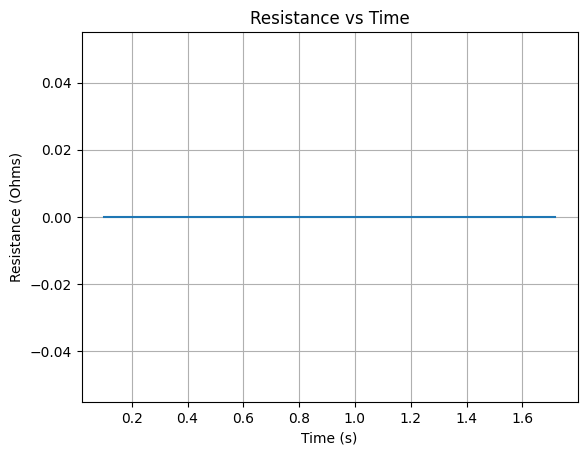

In [4]:
elettrometro = ElettrometroKeithley(selected_port)

elettrometro.init_resistance_reading()

elettrometro.start_continuous_read()

time.sleep(2)

elettrometro.stop_continuous_read()

elettrometro.close()

print("Time buffer:", elettrometro.time_buffer)
print("Resistance buffer:", elettrometro.read_buffer)

plt.plot(elettrometro.time_buffer, elettrometro.read_buffer)
plt.xlabel("Time (s)")
plt.ylabel("Resistance (Ohms)")
plt.title("Resistance vs Time")
plt.grid()
plt.show()